## Explainability

A model that just outputs "churned" or "not churned" isn't useful to a business — they need to know why. This notebook uses SHAP (SHapley Additive Explanations) to explain what drives each prediction, both globally across all customers and for individual customers.

This is the part that turns a data science project into a business tool.

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# reload data
df = pd.read_csv('../data/features.csv')

leaky_features = ['frequency', 'unique_categories', 'total_items']
X = df.drop(columns=['customer_unique_id', 'churned'] + leaky_features)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# retrain best model
best_params = {
    'n_estimators': 633,
    'learning_rate': 0.0523826786760206,
    'num_leaves': 39,
    'max_depth': 9,
    'min_child_samples': 64,
    'subsample': 0.6338605904051074,
    'colsample_bytree': 0.923591149325358,
    'class_weight': 'balanced',
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMClassifier(**best_params)
model.fit(X_train, y_train)

print("Model ready")
print("Features:", list(X.columns))

Model ready
Features: ['recency', 'monetary', 'avg_delivery_delay', 'max_delivery_delay', 'late_deliveries', 'avg_installments', 'unique_payment_types', 'used_voucher', 'avg_item_price', 'max_item_price', 'avg_product_weight', 'avg_freight_value', 'avg_review_score', 'min_review_score', 'gave_bad_review']


In [3]:
# create shap explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# for binary classification lightgbm returns a list of 2 arrays
# we want the second one (probability of churn = 1)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print("SHAP values shape:", sv.shape)

SHAP values shape: (11073, 15)


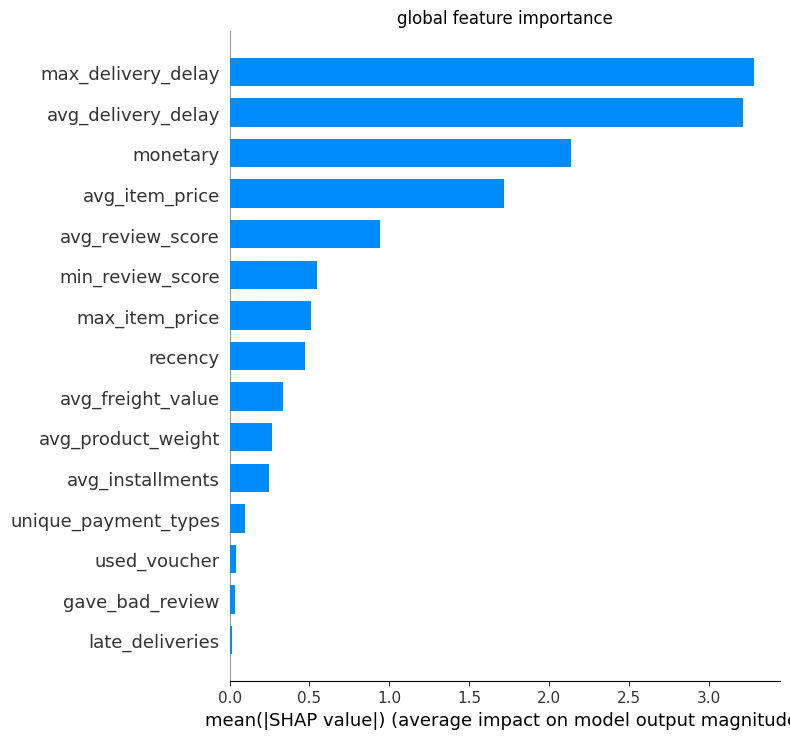

In [4]:
plt.figure()
shap.summary_plot(sv, X_test, plot_type='bar', show=False)
plt.title('global feature importance')
plt.tight_layout()
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Delivery delay is the single biggest driver of churn — both max and average delivery delay sit at the top, far above everything else. This is a powerful business insight: customers don't leave because of price or product, they leave because their order arrived late.

Monetary and item price matter — but less than delivery. Customers who spent more are somewhat more likely to return, but it's secondary to the delivery experience.

Review scores have moderate influence — avg_review_score ranks 5th, confirming that unhappy customers do churn more, but it's downstream of the delivery problem.

Recency ranks surprisingly low — given how separable it looked in the histogram earlier, this suggests LightGBM is extracting the churn signal more from delivery and spend patterns than raw time since last purchase.

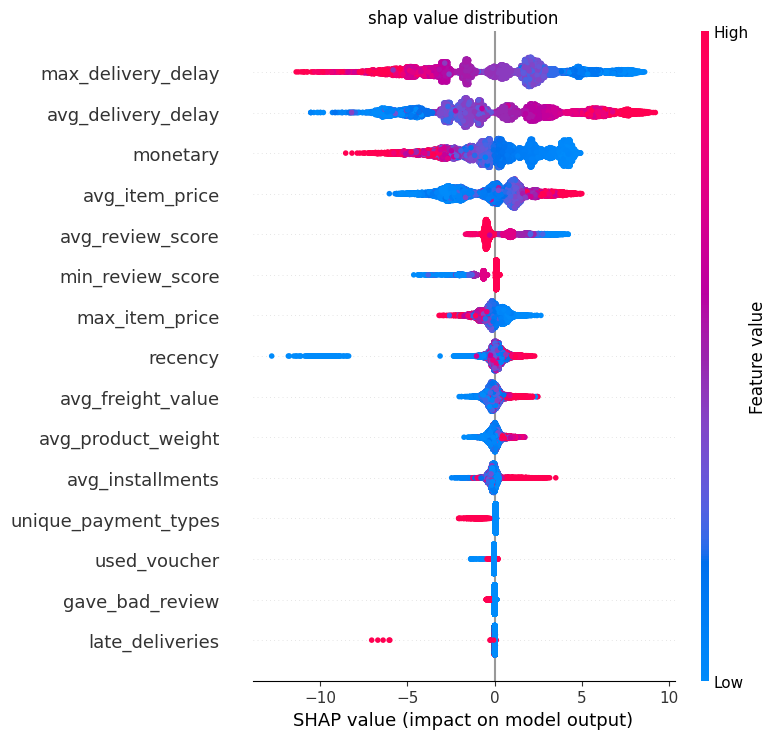

In [5]:
plt.figure()
shap.summary_plot(sv, X_test, show=False)
plt.title('shap value distribution')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Findings

Delivery experience is the dominant driver of churn. Customers who experienced long delivery delays are strongly predicted to churn, while those who received orders on time or early are more likely to return.

Review scores behave as expected — customers who left high scores are pushed toward retained while low scores push toward churn.

Interestingly, high monetary value pushes toward churn rather than retention. This suggests that large one-time purchases are common but don't translate into loyalty — a key insight for any e-commerce business trying to convert big spenders into repeat customers.

Recency has a sharp effect for recently active customers but limited influence overall, as most churned customers share similarly high recency values making it hard for the model to differentiate between them on that dimension alone.

In [7]:
print("expected_value type:", type(explainer.expected_value))
print("expected_value:", explainer.expected_value)

expected_value type: <class 'numpy.float64'>
expected_value: 10.2458718356131


Retained customer explanation


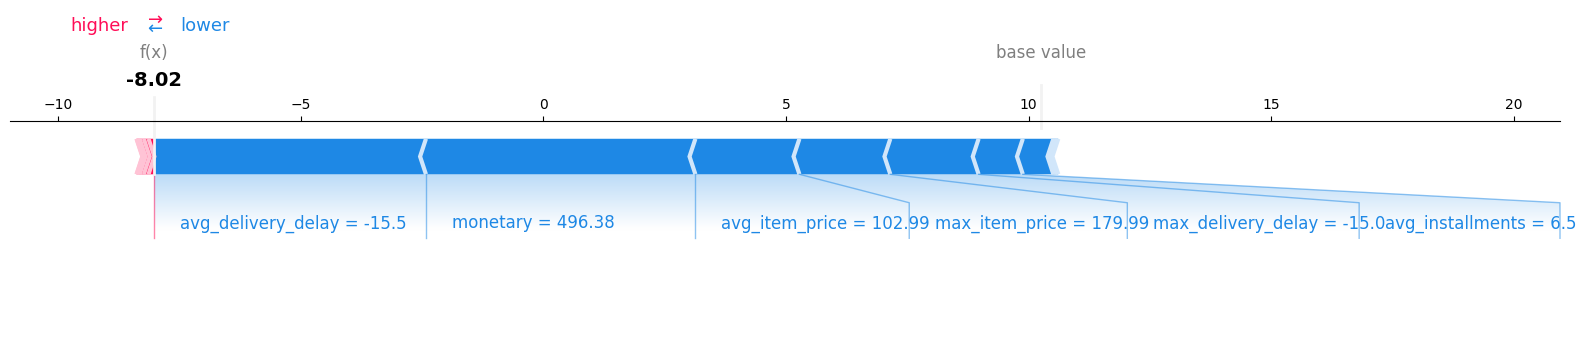

In [8]:
print("Retained customer explanation")
shap.force_plot(
    explainer.expected_value,
    sv[retained_pos],
    X_test.iloc[retained_pos],
    matplotlib=True,
    show=False
)
plt.savefig('../data/shap_retained.png', dpi=150, bbox_inches='tight')
plt.show()

The model output is -8.02 which is a strong prediction toward retained (negative = not churned).
The blue bars push the prediction left toward retained. The biggest contributor is avg_delivery_delay = -15.5 — this customer received their order 15.5 days early on average. That's the single biggest reason the model thinks they'll come back. Combined with high monetary spend (496.38) and decent item prices, everything points toward a loyal customer.
The tiny pink bar on the left is a small push toward churn but it's negligible compared to the blue forces.

Churned customer explanation


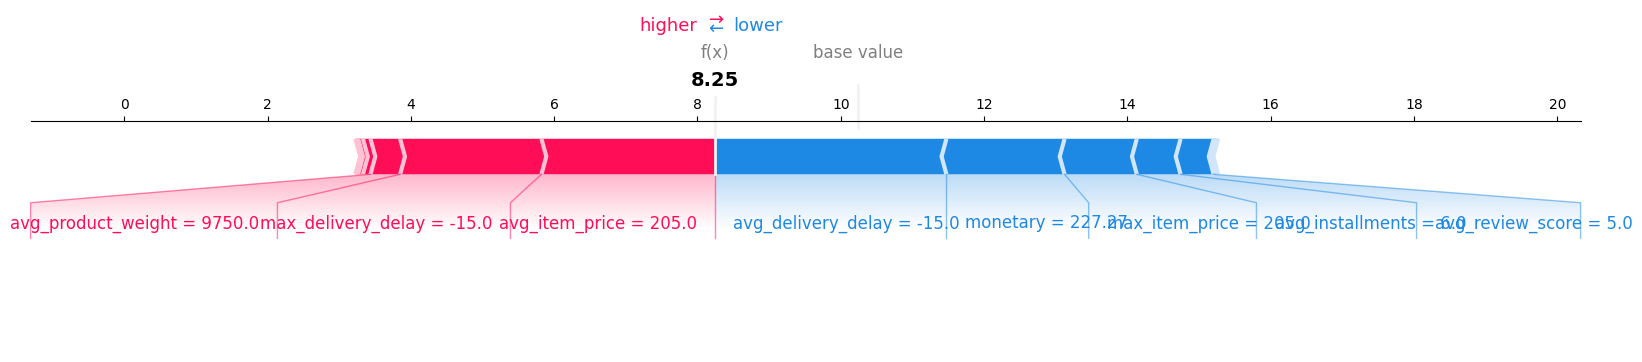

In [9]:
print("Churned customer explanation")
shap.force_plot(
    explainer.expected_value,
    sv[churned_pos],
    X_test.iloc[churned_pos],
    matplotlib=True,
    show=False
)
plt.savefig('../data/shap_churned.png', dpi=150, bbox_inches='tight')
plt.show()

## Individual Explanations

For a retained customer, the dominant factor was receiving orders 15.5 days early on average combined with high spend. The model strongly associates good delivery experience with loyalty.

For a churned customer, the biggest driver was a very heavy product purchase (9,750g) at a high price point — a classic one-time big item purchase pattern. Even though this customer had decent monetary value, the product type signals a one-off transaction rather than habitual buying.

These individual explanations are what make the model actionable for a business — instead of just knowing who will churn, the team can understand why and design targeted interventions accordingly.